<a href="https://colab.research.google.com/github/sserine/econometrics/blob/main/LP_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ======================================================================
# [최종본] 국소투영법(LP) 유가 충격 영향 분석 (90% 신뢰구간 및 개별 그래프)
# ======================================================================

# 1. 초기화 및 필수 라이브러리 로드
!rm *.xlsx *.xls *.csv 2>/dev/null
from google.colab import files
import pandas as pd
import numpy as np
import io
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.unicode_minus'] = False

# 파일 업로드 실행
print("데이터 파일(CSV 또는 Excel)을 업로드해주세요.")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

데이터 파일(CSV 또는 Excel)을 업로드해주세요.


Saving data_eng (2000~.xlsx to data_eng (2000~.xlsx


In [2]:
# 2. 데이터 불러오기 및 전처리
if filename.endswith('.csv'):
    try:
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
    except UnicodeDecodeError:
        df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='cp949')
else:
    df = pd.read_excel(io.BytesIO(uploaded[filename]))

# 결측치 및 특수문자 처리
df = df.replace('-', np.nan)
if 'Fuel_Tax_Cut' in df.columns:
    df['Fuel_Tax_Cut'] = df['Fuel_Tax_Cut'].fillna(0)

# 날짜 변환 및 정렬
time_col = 'Date'
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# 숫자형 강제 변환
for col in df.columns:
    if col != time_col:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"실질 분석 기간: {df[time_col].min().date()} ~ {df[time_col].max().date()}\n")

실질 분석 기간: 2000-01-01 ~ 2026-04-01



/tmp/ipykernel_1055/3823873356.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('-', np.nan)


In [3]:
# 3. 주요 거시경제 변수 생성 (로그 변환 및 차분)
df['Oil_KRW'] = df['Dubai_Oil'] * df['FX_Rate'] # 원화 환산 유가

df['log_CPI'] = np.log(df['Total CPI'])
df['log_Oil_KRW'] = np.log(df['Oil_KRW'])
df['log_IP'] = np.log(df['IP'])

df['d_CPI'] = df['log_CPI'].diff() * 100
df['d_Oil_KRW'] = df['log_Oil_KRW'].diff() * 100
df['d_IP'] = df['log_IP'].diff() * 100
df['d_Rate'] = df['Gov_Bond_3Y'].diff()

단위근 검정 ADF

In [8]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# 단위근 검정 결과를 출력하는 사용자 정의 함수
def run_adf_test(series, var_name):
    print(f"==== [{var_name}] ADF 단위근 검정 결과 ====")

    # 결측치(NaN)가 있으면 검정이 불가하므로 제거
    clean_series = series.dropna()

    # ADF 검정 수행
    result = adfuller(clean_series, autolag='AIC')

    adf_stat = result[0]
    p_value = result[1]
    critical_values = result[4]

    print(f"검정통계량 (ADF Statistic): {adf_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("임계값 (Critical Values):")
    for key, value in critical_values.items():
        print(f"  {key}: {value:.4f}")

    # p-value가 0.05보다 작으면 정상성 확보로 판단
    if p_value < 0.05:
        print("결론: 귀무가설 기각 -> 시계열이 안정적(Stationary)입니다. (회귀분석 사용 가능)\n")
    else:
        print("결론: 귀무가설 기각 불가 -> 시계열에 단위근이 존재(Non-stationary)합니다. (차분 필요)\n")

# 1. 차분하기 전 원수준 금리 데이터 검정
run_adf_test(df['Gov_Bond_3Y'], '원수준 금리 (Gov_Bond_3Y)')

# 2. 차분한 후의 금리 데이터 검정 (앞서 추가하신 차분 코드)
# df['d_Rate'] = df['Gov_Bond_3Y'].diff() # 이미 3단계에 있다면 이 줄은 생략 가능
run_adf_test(df['d_Rate'], '차분된 금리 (d_Rate)')

==== [원수준 금리 (Gov_Bond_3Y)] ADF 단위근 검정 결과 ====
검정통계량 (ADF Statistic): -2.3078
p-value: 0.1695
임계값 (Critical Values):
  1%: -3.4520
  5%: -2.8711
  10%: -2.5719
결론: 귀무가설 기각 불가 -> 시계열에 단위근이 존재(Non-stationary)합니다. (차분 필요)

==== [차분된 금리 (d_Rate)] ADF 단위근 검정 결과 ====
검정통계량 (ADF Statistic): -4.8524
p-value: 0.0000
임계값 (Critical Values):
  1%: -3.4520
  5%: -2.8711
  10%: -2.5719
결론: 귀무가설 기각 -> 시계열이 안정적(Stationary)입니다. (회귀분석 사용 가능)



In [14]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def generate_unit_root_table(df, variables):
    print("==== 주요 거시 변수 ADF 단위근 검정 요약표 ====")
    results = []

    for var in variables:
        # 결측치 제거 후 검정
        clean_series = df[var].dropna()

        # ADF 검정 수행
        adf_result = adfuller(clean_series, autolag='AIC')
        stat = adf_result[0]
        p_value = adf_result[1]

        # 통계적 유의성 별표(Asterisk) 부여 (p-value 기준)
        stars = ""
        if p_value < 0.01:
            stars = "***"
        elif p_value < 0.05:
            stars = "**"
        elif p_value < 0.1:
            stars = "*"

        results.append({
            'Variable': var,
            'ADF Stat': f"{stat:.4f}{stars}",
            'p-value': f"{p_value:.4f}",
            'Stationary?': 'Yes' if p_value < 0.05 else 'No'
        })

    # 데이터프레임으로 변환하여 출력
    summary_df = pd.DataFrame(results)
    return summary_df

# 1. 작성하신 3단계 변수 목록에 맞춘 최종 통제변수 리스트 지정
final_vars = ['d_CPI', 'd_Oil_KRW', 'd_IP', 'd_Rate']

# 2. 결과 표 생성 및 출력
unit_root_summary = generate_unit_root_table(df, final_vars)
print(unit_root_summary.to_string(index=False))

==== 주요 거시 변수 ADF 단위근 검정 요약표 ====
 Variable    ADF Stat p-value Stationary?
    d_CPI   -3.1569**  0.0226         Yes
d_Oil_KRW -11.1113***  0.0000         Yes
     d_IP  -7.6111***  0.0000         Yes
   d_Rate  -4.8524***  0.0000         Yes


단위근 검정 PP검정

In [11]:
#arch 라이브러리 설치 (코랩 환경)
!pip install arch

import pandas as pd
from arch.unitroot import PhillipsPerron

# PP 단위근 검정 결과를 출력하는 사용자 정의 함수
def run_pp_test(series, var_name):
    print(f"==== [{var_name}] Phillips-Perron (PP) 단위근 검정 결과 ====")

    # 결측치(NaN)가 있으면 검정이 불가하므로 제거
    clean_series = series.dropna()

    # PP 검정 수행
    pp_test = PhillipsPerron(clean_series)

    # 요약 결과 출력
    print(pp_test.summary().as_text())

    # p-value 추출 및 결론 도출
    p_value = pp_test.pvalue

    if p_value < 0.05:
        print(f"\n결론: p-value({p_value:.4f}) < 0.05 이므로 귀무가설 기각")
        print("-> 시계열이 안정적(Stationary)입니다. (회귀분석 사용 가능)\n")
    else:
        print(f"\n결론: p-value({p_value:.4f}) >= 0.05 이므로 귀무가설 기각 불가")
        print("-> 시계열에 단위근이 존재(Non-stationary)합니다. (차분 필요)\n")

# 1. 차분하기 전 원수준 금리 데이터 검정
run_pp_test(df['Gov_Bond_3Y'], '원수준 금리 (Gov_Bond_3Y)')

# 2. 차분한 후의 금리 데이터 검정
run_pp_test(df['d_Rate'], '차분된 금리 (d_Rate)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 21.1 MB/s eta 0:00:00
==== [원수준 금리 (Gov_Bond_3Y)] Phillips-Perron (PP) 단위근 검정 결과 ====
     Phillips-Perron Test (Z-tau)    
Test Statistic                 -3.544
P-value                         0.007
Lags                               16
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

결론: p-value(0.0069) < 0.05 이므로 귀무가설 기각
-> 시계열이 안정적(Stationary)입니다. (회귀분석 사용 가능)

==== [차분된 금리 (d_Rate)] Phillips-Perron (PP) 단위근 검정 결과 ====
     Phillips-Perron Test (Z-tau)    
Test Statistic                -11.985
P-value                         0.000
Lags                               16
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The proces

In [4]:
# 4. 구조적 이벤트 더미 및 교호작용항 생성 (총 6개 국면)
events = {
    'Demand Surge': ('2007-01-01', '2009-12-31'),
    'Arabic Spring': ('2010-12-01', '2011-11-30'),
    'Shale': ('2014-06-01', '2016-12-31'),
    'Saudi_terror': ('2019-09-01', '2019-12-31'),
    'COVID': ('2020-01-01', '2021-12-31'),
    'Russia-Ukraine': ('2022-02-01', '2025-12-31')
}

dummy_cols = []
interaction_cols = []

for event_name, (start, end) in events.items():
    dummy_name = f'Dummy_{event_name}'
    int_name = f'Int_{event_name}'

    df[dummy_name] = np.where((df[time_col] >= start) & (df[time_col] <= end), 1, 0)
    df[int_name] = df[dummy_name] * df['d_Oil_KRW']

    dummy_cols.append(dummy_name)
    interaction_cols.append(int_name)


In [5]:
# 5. 통제변수 과거 시차 생성
p = 3
control_lags = []
for i in range(1, p + 1):
  for var in ['d_Oil_KRW', 'd_CPI', 'd_IP', 'd_Rate']:
        col_name = f'{var}_lag{i}'
        df[col_name] = df[var].shift(i)
        control_lags.append(col_name)

# 분석에 투입할 독립변수 리스트 구성
X_base_cols = ['d_Oil_KRW'] + dummy_cols + interaction_cols + control_lags

In [6]:
# 6. 시차별 국소투영법(LP) 추정 루프 실행
h_max = 24
results_dict = {event: [] for event in events.keys()}
results_dict['Baseline'] = []
r2_list = []

# 90% 신뢰구간 임계값 설정 (Z = 1.645)
z_score = 1.645

print("==================================================")
print(" 전체 데이터 통합 국소투영법(LP) 추정 중 (HAC 적용) ")
print("==================================================")

for h in range(h_max + 1):
    target_col = f'Y_h{h}'
    df[target_col] = (df['log_CPI'].shift(-h) - df['log_CPI'].shift(1)) * 100

    reg_df = df[['Date', target_col] + X_base_cols].dropna()
    Y = reg_df[target_col]
    X = sm.add_constant(reg_df[X_base_cols])

    model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})
    cov_matrix = model.cov_params()

    r2_list.append([h, round(model.rsquared_adj, 4)])

    # 1) Baseline 효과 저장 (90% 신뢰구간 적용)
    beta_base = model.params['d_Oil_KRW']
    se_base = model.bse['d_Oil_KRW']
    results_dict['Baseline'].append([
        h, round(beta_base, 4), round(se_base, 4),
        round(beta_base - z_score*se_base, 4), round(beta_base + z_score*se_base, 4)
    ])

    # 2) 이벤트별 총 파급 효과 계산 및 선형결합 오차 추출
    for event_name in events.keys():
        int_col = f'Int_{event_name}'

        if int_col in model.params and not np.isnan(model.params[int_col]):
            theta = model.params[int_col]
            try:
                var_theta = cov_matrix.loc[int_col, int_col]
                cov_beta_theta = cov_matrix.loc['d_Oil_KRW', int_col]
            except KeyError:
                var_theta, cov_beta_theta = 0, 0
        else:
            theta, var_theta, cov_beta_theta = 0, 0, 0

        total_effect = beta_base + theta
        var_total = (cov_matrix.loc['d_Oil_KRW', 'd_Oil_KRW'] + var_theta + 2 * cov_beta_theta)
        se_total = np.sqrt(abs(var_total))

        results_dict[event_name].append([
            h, round(total_effect, 4), round(se_total, 4),
            round(total_effect - z_score*se_total, 4), round(total_effect + z_score*se_total, 4)
        ])

 전체 데이터 통합 국소투영법(LP) 추정 중 (HAC 적용) 



 1. 주요 시점별 유가 충격의 물가 전이 효과 요약 (90% CI) 

[Baseline]
 h  CPI_Impact(%p)     SE  Lower_90  Upper_90
 1          0.0203 0.0065    0.0097    0.0310
 3          0.0236 0.0088    0.0091    0.0381
 6          0.0188 0.0102    0.0021    0.0355
12          0.0406 0.0126    0.0199    0.0613
24          0.0372 0.0183    0.0071    0.0673

[Demand Surge]
 h  CPI_Impact(%p)     SE  Lower_90  Upper_90
 1          0.0305 0.0088    0.0159    0.0450
 3          0.0371 0.0157    0.0113    0.0630
 6          0.0152 0.0136   -0.0072    0.0376
12          0.0297 0.0154    0.0044    0.0551
24          0.0160 0.0133   -0.0059    0.0379

[Arabic Spring]
 h  CPI_Impact(%p)     SE  Lower_90  Upper_90
 1          0.0368 0.0209    0.0025    0.0711
 3          0.0373 0.0306   -0.0130    0.0877
 6          0.0704 0.0275    0.0251    0.1156
12          0.0747 0.0278    0.0290    0.1204
24          0.0795 0.0298    0.0305    0.1285

[Shale]
 h  CPI_Impact(%p)     SE  Lower_90  Upper_90
 1         -0.0000 0.0073   -0.

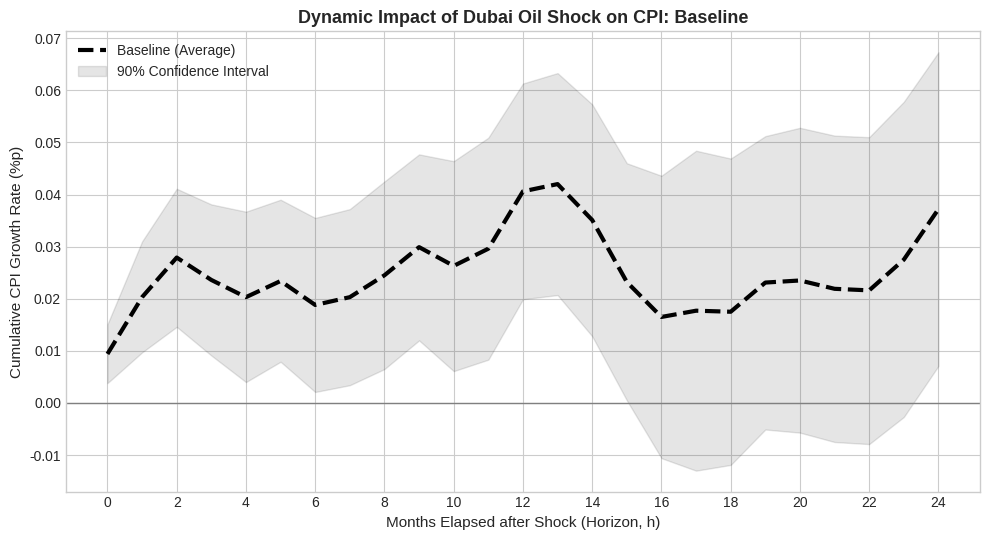

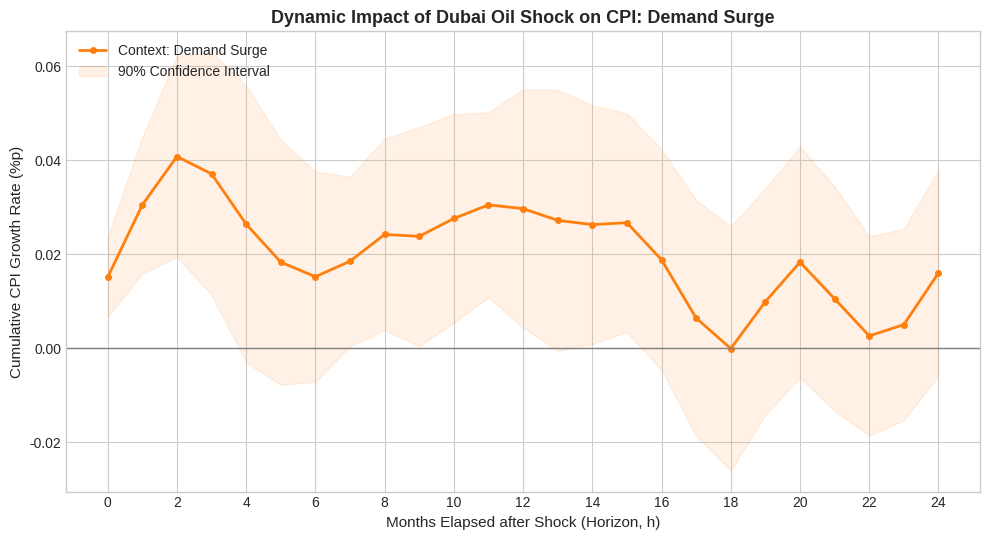

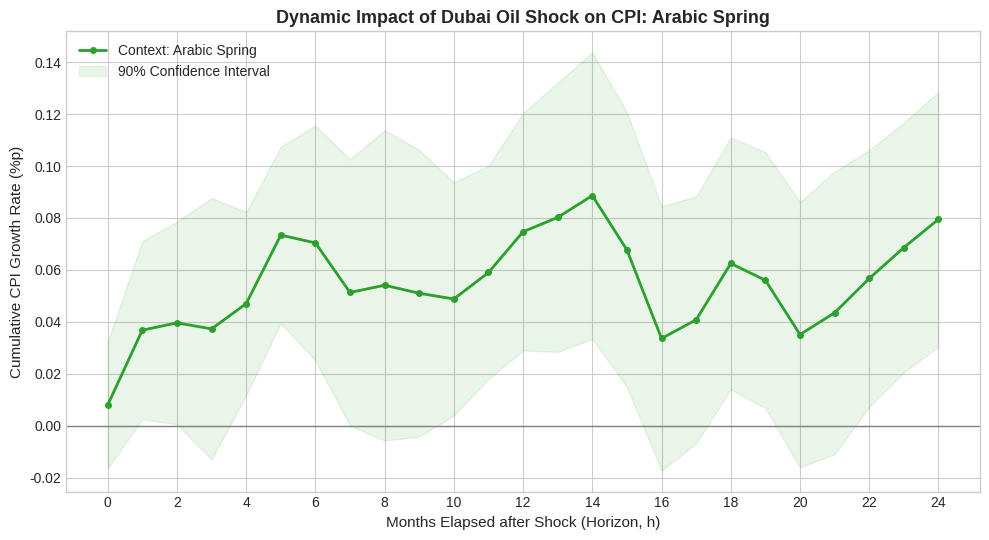

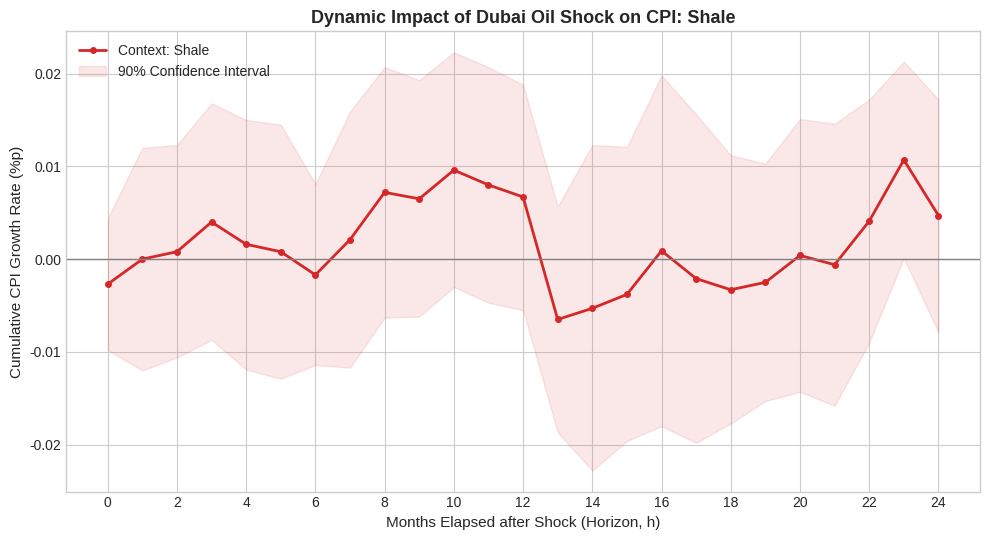

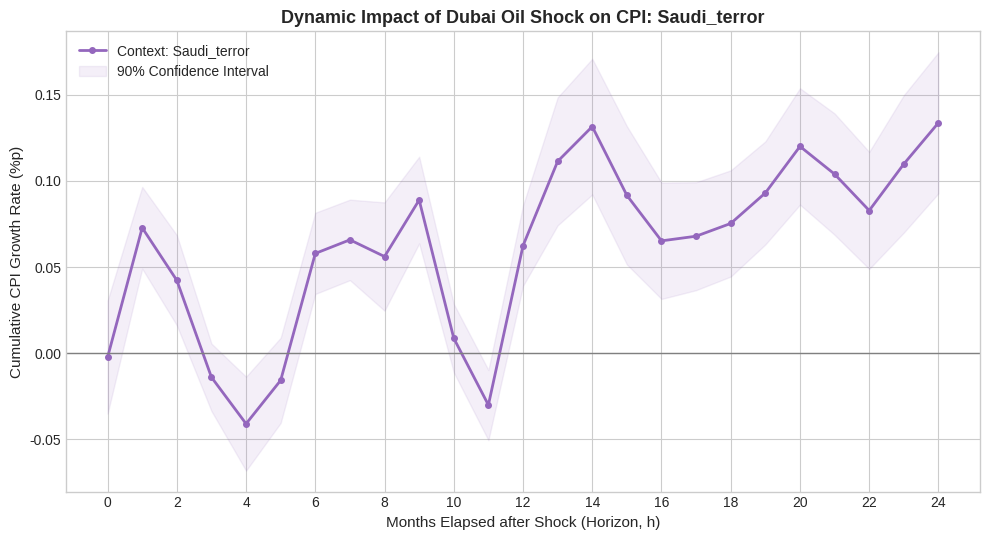

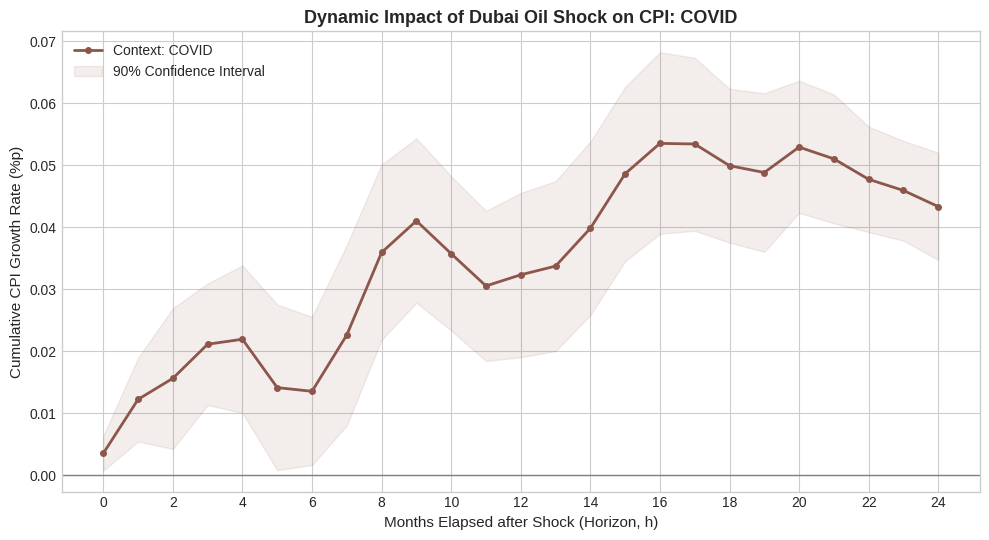

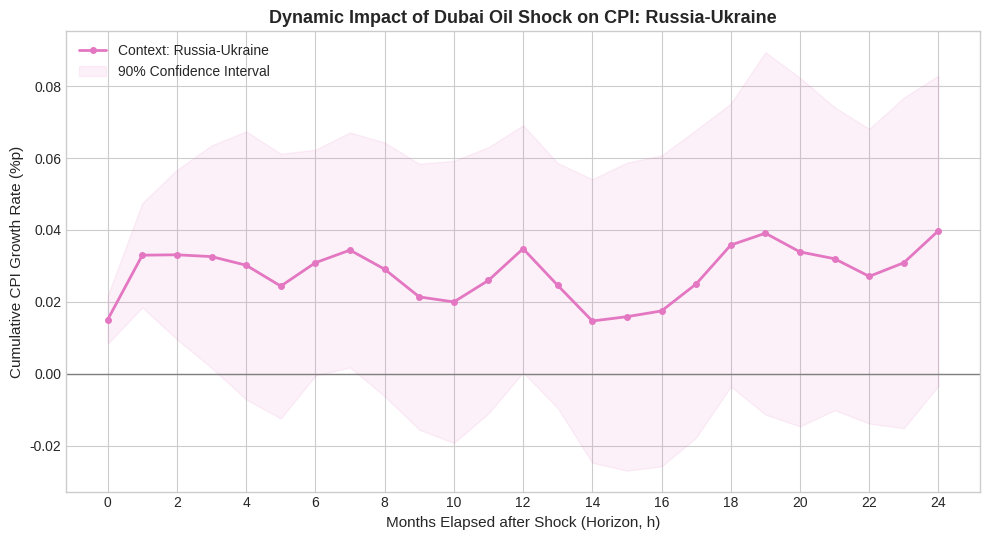

In [7]:
# 7. 분석 결과 및 구조적 설명력 요약 표 출력 (90% 신뢰구간 반영)
summary_h = [1, 3, 6, 12, 24]
cols = ['h', 'CPI_Impact(%p)', 'SE', 'Lower_90', 'Upper_90']

print("\n==================================================")
print(" 1. 주요 시점별 유가 충격의 물가 전이 효과 요약 (90% CI) ")
print("==================================================")
for key in ['Baseline'] + list(events.keys()):
    df_res = pd.DataFrame(results_dict[key], columns=cols)
    print(f"\n[{key}]")
    print(df_res[df_res['h'].isin(summary_h)].to_string(index=False))

print("\n" + "="*50)
print(" 2. 시차(h)별 모형의 수정된 결정계수 (Adj. R-squared) ")
print("="*50)
df_r2 = pd.DataFrame(r2_list, columns=['h', 'Adj. R-squared'])
print(df_r2[df_r2['h'].isin(summary_h)].to_string(index=False))


# 8. 최종 결과 시각화 (각 이벤트별 개별 그래프 순차 출력)
print("\n==================================================")
print(" 3. 국면별 동태적 충격반응함수(IRF) 개별 그래프 출력 ")
print("==================================================")

all_plots = ['Baseline'] + list(events.keys())
color_palette = ['#000000', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
plot_colors = dict(zip(all_plots, color_palette))

for key in all_plots:
    df_ev = pd.DataFrame(results_dict[key], columns=cols)

    # 데이터가 없거나 모두 0인 경우 출력 패스
    if df_ev['CPI_Impact(%p)'].isna().all() or (df_ev['CPI_Impact(%p)'] == 0).all():
        continue

    plt.figure(figsize=(10, 5.5))

    # Baseline은 검은색 점선, 개별 국면은 고유 색상 실선으로 차별화
    if key == 'Baseline':
        plt.plot(df_ev['h'], df_ev['CPI_Impact(%p)'], color=plot_colors[key], linestyle='--', linewidth=3, label='Baseline (Average)')
    else:
        plt.plot(df_ev['h'], df_ev['CPI_Impact(%p)'], color=plot_colors[key], marker='o', markersize=4, linewidth=2, label=f'Context: {key}')

    # 90% 신뢰구간 면적 채우기
    plt.fill_between(df_ev['h'], df_ev['Lower_90'], df_ev['Upper_90'], color=plot_colors[key], alpha=0.1, label='90% Confidence Interval')

    # 가이드라인 및 서식 추가
    plt.axhline(0, color='gray', linestyle='-', linewidth=1)
    plt.title(f'Dynamic Impact of Dubai Oil Shock on CPI: {key}', fontsize=13, fontweight='bold')
    plt.xlabel('Months Elapsed after Shock (Horizon, h)', fontsize=11)
    plt.ylabel('Cumulative CPI Growth Rate (%p)', fontsize=11)
    plt.xticks(np.arange(0, h_max + 1, 2))
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()